In [1]:
!pip install yfinance matplotlib python-benedict --quiet

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import benedict
from datetime import datetime

In [3]:
plt.rcParams['figure.figsize'] = [20, 10]

In [4]:
def get_ticker_from_yahoo(ticker):
    
    ticker_df = yf.Ticker(ticker).history(period='max', auto_adjust=True)
    
    template_df = pd.DataFrame(
        index=pd.date_range(
            start=ticker_df.index[0],
            end=ticker_df.index[-1],
            freq='1D'
        )
    )
    
    template_df = template_df.merge(ticker_df, how='left', left_index=True, right_index=True)
    
    return template_df

In [5]:
usd_brl_df = get_ticker_from_yahoo('USDBRL=X')
usd_brl_df.columns = [f'USDBRL_{c}' for c in usd_brl_df.columns]

In [6]:
usd_brl_df.head()

,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits
2003-12-01,2.946,2.946,2.923,2.923,0.0,0.0,0.0
2003-12-02,2.923,2.931,2.923,2.931,0.0,0.0,0.0
2003-12-03,2.931,2.936,2.926,2.931,0.0,0.0,0.0
2003-12-04,2.931,2.943,2.931,2.943,0.0,0.0,0.0
2003-12-05,2.943,2.948,2.934,2.934,0.0,0.0,0.0


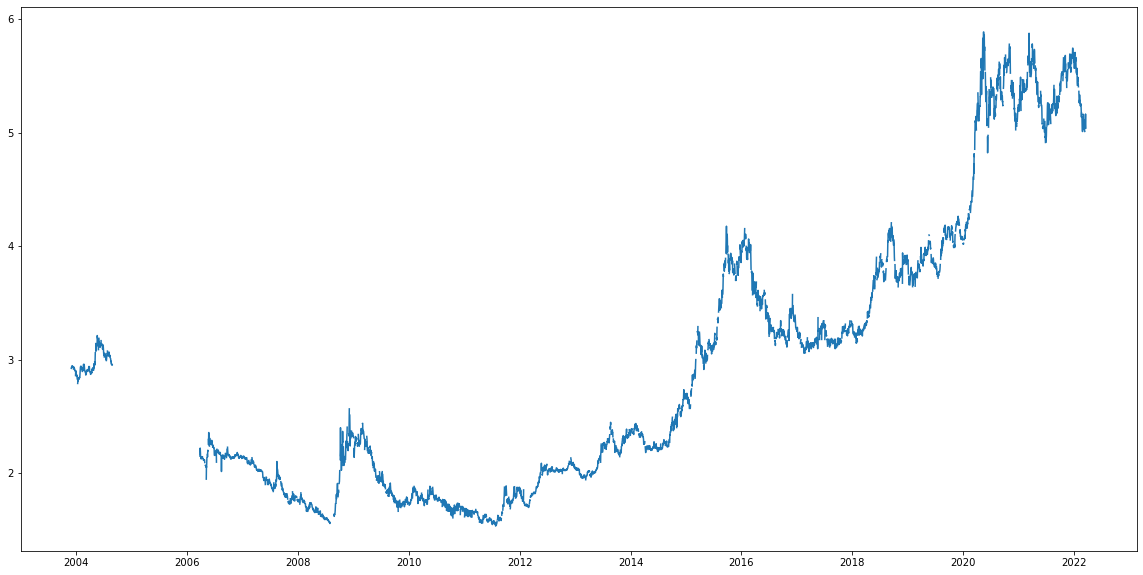

In [7]:
plt.plot(usd_brl_df.index, usd_brl_df['USDBRL_Close'])

In [8]:
ibov_yahoo_df = get_ticker_from_yahoo('^BVSP')
ibov_yahoo_df.columns = [f'IBOV_YAHOO_{c}' for c in ibov_yahoo_df.columns]

In [9]:
ibov_yahoo_df.head()

,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits
1993-04-27,24.799999,25.400000,24.500000,24.500000,0.0,0.0,0.0
1993-04-28,24.500000,24.600000,23.700001,24.299999,0.0,0.0,0.0
1993-04-29,24.299999,24.799999,23.700001,23.700001,0.0,0.0,0.0
1993-04-30,23.700001,24.200001,23.700001,24.100000,0.0,0.0,0.0
1993-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


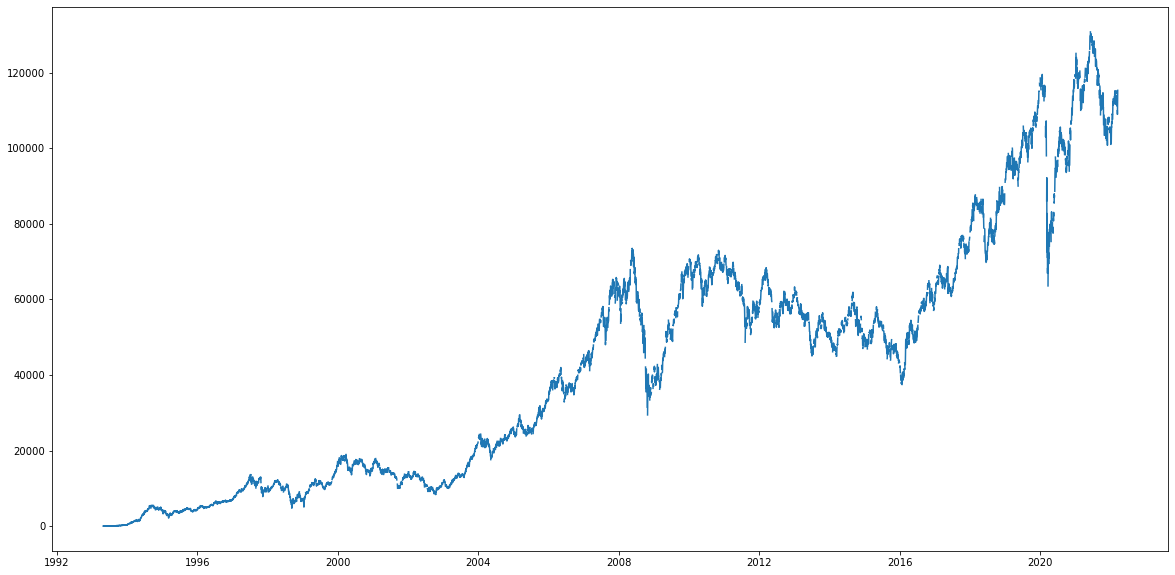

In [10]:
plt.plot(ibov_yahoo_df.index, ibov_yahoo_df['IBOV_YAHOO_Close'])

In [11]:
ibov_yahoo_df = ibov_yahoo_df.merge(usd_brl_df, how='left', left_index=True, right_index=True)

In [12]:
ibov_yahoo_df.head()

,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits
1993-04-27,24.799999,25.400000,24.500000,24.500000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-28,24.500000,24.600000,23.700001,24.299999,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-29,24.299999,24.799999,23.700001,23.700001,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-30,23.700001,24.200001,23.700001,24.100000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
ibov_yahoo_df.head()

,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits
1993-04-27,24.799999,25.400000,24.500000,24.500000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-28,24.500000,24.600000,23.700001,24.299999,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-29,24.299999,24.799999,23.700001,23.700001,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-04-30,23.700001,24.200001,23.700001,24.100000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
ibov_yahoo_df['IBOV_YAHOO_Close_USD'] = ibov_yahoo_df['IBOV_YAHOO_Close'] / ibov_yahoo_df['USDBRL_Close']

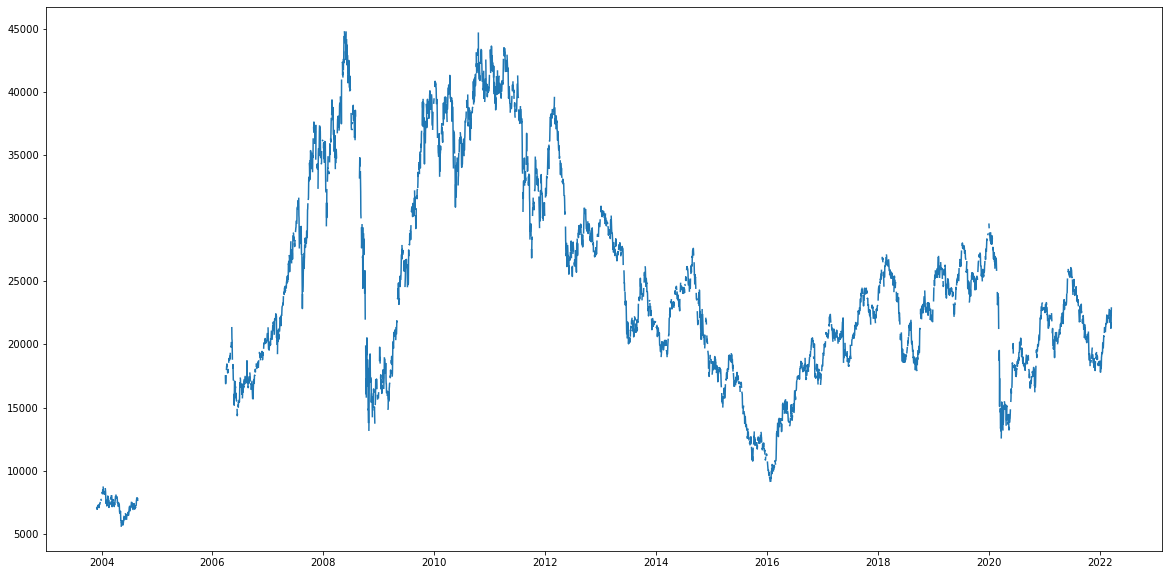

In [15]:
plt.plot(ibov_yahoo_df.index, ibov_yahoo_df['IBOV_YAHOO_Close_USD'])

In [16]:
def read_ibov_df(filename: str) -> pd.DataFrame:
    data_points = []
    xml = benedict.benedict.from_xml(filename)
    for data_point in xml['Result.Poster.Serie.barras.B']:
        data_points.append({
            'Date': datetime.strptime(data_point['@d'], '%Y-%m-%d'),
            'Close': data_point['@C']
        })
    df = pd.DataFrame(data_points)
    df['Close'] = df['Close'].astype(float)
    df = df.sort_values('Date')
    df = df.set_index('Date')
    return df

In [17]:
ibov_1963_df = read_ibov_df('ibovusd1963.xml')

In [18]:
ibov_1963_df.head()

,Close
Date,
1963-01-01,62.0
1963-02-01,65.0
1963-03-01,60.0
1963-04-01,57.0
1963-05-01,52.0


In [19]:
ibov_1963_df = ibov_1963_df.merge(ibov_yahoo_df, how='outer', left_index=True, right_index=True)

In [20]:
ibov_1963_df[3500:].head(n=50)

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2001-11-27,NaN,13771.0,13791.0,13490.0,13603.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-28,NaN,13553.0,13553.0,12913.0,13019.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-29,NaN,13019.0,13187.0,12622.0,12736.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-30,NaN,12744.0,13053.0,12704.0,12932.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-03,5865.0,12914.0,13336.0,12870.0,13336.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-04,NaN,13374.0,13565.0,13071.0,13147.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-05,NaN,13186.0,13382.0,13103.0,13382.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-06,NaN,13382.0,13575.0,13230.0,13539.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
ibov_1963_df.tail()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2022-03-14,NaN,111716.0,112299.0,109717.0,109928.0,10480900.0,0.0,0.0,5.073100,5.0838,5.037000,5.073500,0.0,0.0,0.0,21667.093054
2022-03-15,NaN,109925.0,109925.0,107781.0,108959.0,13653800.0,0.0,0.0,5.121700,5.1495,5.089902,5.121400,0.0,0.0,0.0,21275.237741
2022-03-16,NaN,108958.0,111183.0,108958.0,111112.0,13205200.0,0.0,0.0,5.163200,5.1637,5.095000,5.163200,0.0,0.0,0.0,21519.988015
2022-03-17,NaN,111113.0,113088.0,111070.0,113076.0,14407500.0,0.0,0.0,5.076000,5.1043,5.040100,5.073875,0.0,0.0,0.0,22285.925669
2022-03-18,NaN,113076.0,115311.0,112475.0,115311.0,19552500.0,0.0,0.0,5.036666,5.0719,5.008420,5.039400,0.0,0.0,0.0,22881.890244


In [22]:
ibov_1963_df['Close'] = ibov_1963_df['Close'].combine_first(ibov_1963_df['IBOV_YAHOO_Close_USD'])

In [23]:
ibov_1963_df[3500:].head(n=50)

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2001-11-27,NaN,13771.0,13791.0,13490.0,13603.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-28,NaN,13553.0,13553.0,12913.0,13019.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-29,NaN,13019.0,13187.0,12622.0,12736.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-30,NaN,12744.0,13053.0,12704.0,12932.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-03,5865.0,12914.0,13336.0,12870.0,13336.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-04,NaN,13374.0,13565.0,13071.0,13147.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-05,NaN,13186.0,13382.0,13103.0,13382.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-06,NaN,13382.0,13575.0,13230.0,13539.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
ibov_1963_df.tail()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2022-03-14,21667.093054,111716.0,112299.0,109717.0,109928.0,10480900.0,0.0,0.0,5.073100,5.0838,5.037000,5.073500,0.0,0.0,0.0,21667.093054
2022-03-15,21275.237741,109925.0,109925.0,107781.0,108959.0,13653800.0,0.0,0.0,5.121700,5.1495,5.089902,5.121400,0.0,0.0,0.0,21275.237741
2022-03-16,21519.988015,108958.0,111183.0,108958.0,111112.0,13205200.0,0.0,0.0,5.163200,5.1637,5.095000,5.163200,0.0,0.0,0.0,21519.988015
2022-03-17,22285.925669,111113.0,113088.0,111070.0,113076.0,14407500.0,0.0,0.0,5.076000,5.1043,5.040100,5.073875,0.0,0.0,0.0,22285.925669
2022-03-18,22881.890244,113076.0,115311.0,112475.0,115311.0,19552500.0,0.0,0.0,5.036666,5.0719,5.008420,5.039400,0.0,0.0,0.0,22881.890244


In [25]:
ibov_1963_df[3500:].head(n=50)

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2001-11-27,NaN,13771.0,13791.0,13490.0,13603.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-28,NaN,13553.0,13553.0,12913.0,13019.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-29,NaN,13019.0,13187.0,12622.0,12736.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-11-30,NaN,12744.0,13053.0,12704.0,12932.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-03,5865.0,12914.0,13336.0,12870.0,13336.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-04,NaN,13374.0,13565.0,13071.0,13147.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-05,NaN,13186.0,13382.0,13103.0,13382.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-06,NaN,13382.0,13575.0,13230.0,13539.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


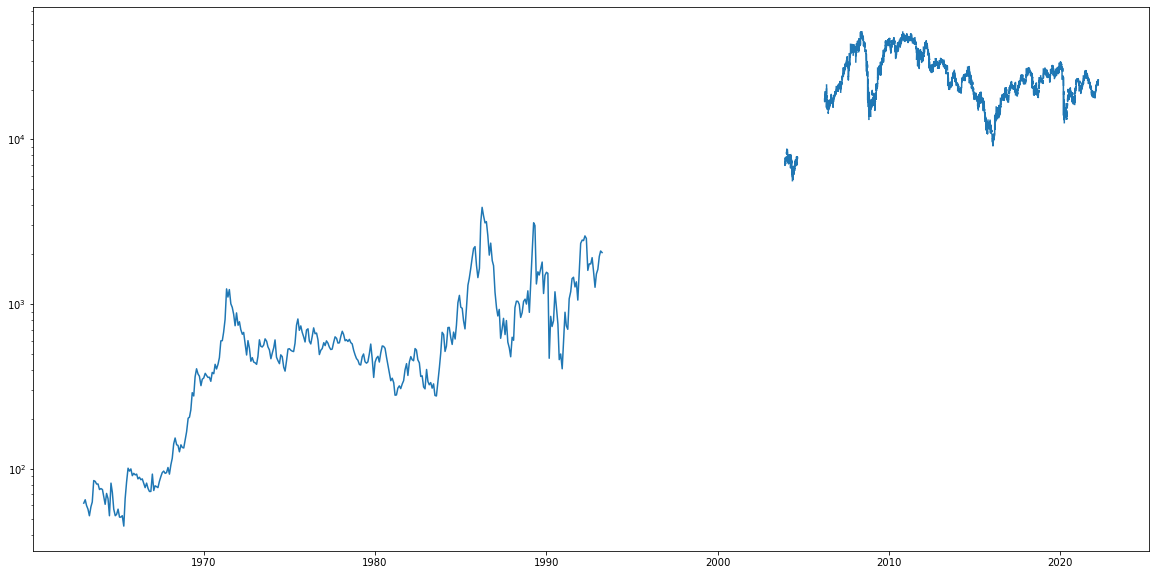

In [26]:
plt.yscale('log')
plt.plot(ibov_1963_df.index, ibov_1963_df['Close'])

In [27]:
ibov_1963_df = ibov_1963_df.resample('M').last()

In [28]:
ibov_1963_df.head()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
1963-01-31,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963-02-28,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963-03-31,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963-04-30,57.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963-05-31,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
ibov_1963_df.tail()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2021-11-30,18196.832859,102814.0,103066.0,100075.0,101915.0,18195100.0,0.0,0.0,5.598604,5.6646,5.578417,5.6007,0.0,0.0,0.0,18196.832859
2021-12-31,18381.117271,104106.0,105269.0,104106.0,104822.0,11138100.0,0.0,0.0,5.569800,5.5906,5.566143,5.5702,0.0,0.0,0.0,18381.117271
2022-01-31,20957.744965,111910.0,112495.0,111195.0,112388.0,12190800.0,0.0,0.0,5.365500,5.3958,5.282676,5.3626,0.0,0.0,0.0,20957.744965
2022-02-28,22088.555646,111591.0,113142.0,110673.0,113142.0,17555700.0,0.0,0.0,5.166000,5.1665,5.151300,5.1594,0.0,0.0,0.0,22088.555646
2022-03-31,22881.890244,113076.0,115311.0,112475.0,115311.0,19552500.0,0.0,0.0,5.036666,5.0719,5.008420,5.0394,0.0,0.0,0.0,22881.890244


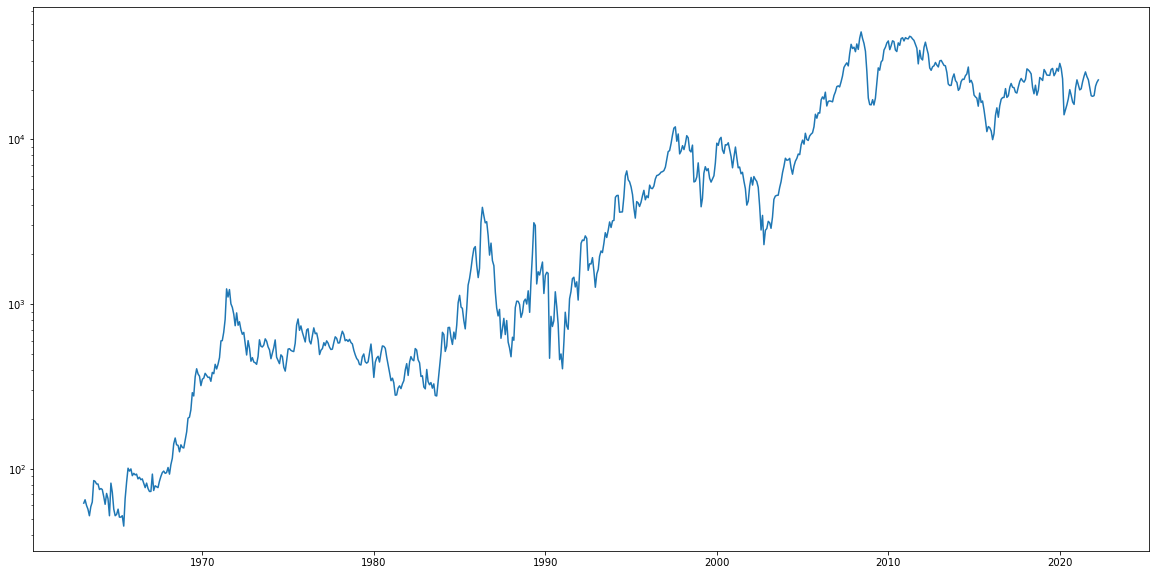

In [30]:
plt.yscale('log')
plt.plot(ibov_1963_df.index, ibov_1963_df['Close'])

In [31]:
ewz_df = get_ticker_from_yahoo('EWZ')

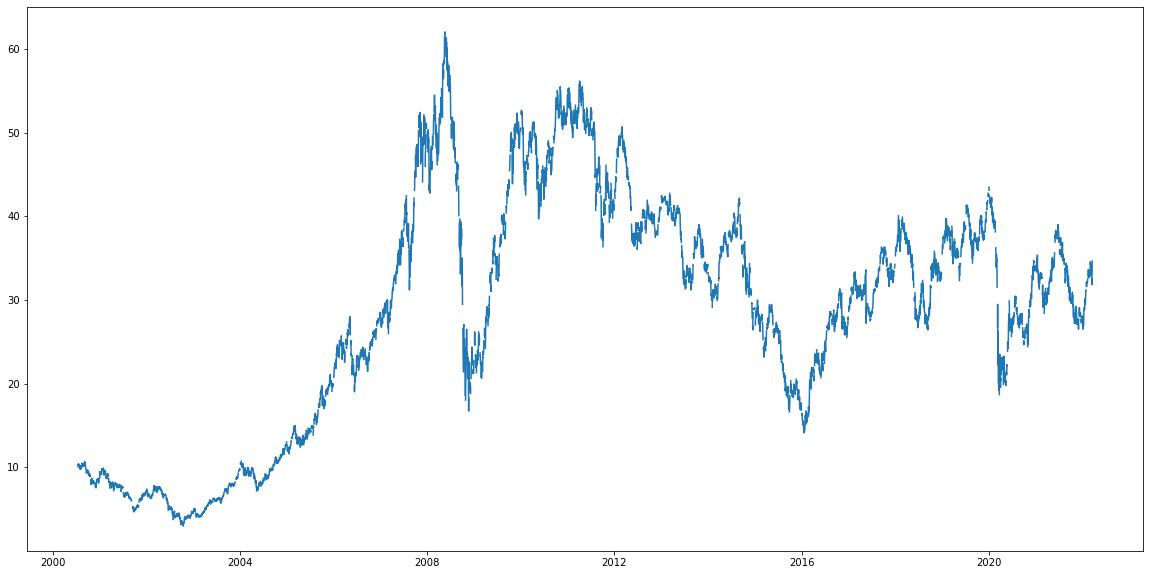

In [32]:
plt.plot(ewz_df.index, ewz_df['Close'])

In [48]:
ewz_df = ewz_df.resample('M').last()

In [49]:
first_common_date = max(ewz_df.index[0], ibov_1963_df.index[0])

In [50]:
first_common_date

Timestamp('2000-07-31 00:00:00', freq='M')

In [51]:
ibov_1963_df = ibov_1963_df.loc[first_common_date:, :]

In [52]:
ibov_1963_df.head()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2000-07-31,1.000000,16487.0,16713.0,16455.0,16455.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-08-31,1.031677,17417.0,17563.0,17327.0,17347.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-09-30,0.936537,16020.0,16135.0,15821.0,15928.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-31,0.848449,14916.0,15099.0,14859.0,14867.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-11-30,0.727598,13779.0,13779.0,13287.0,13287.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
ewz_df = ewz_df[first_common_date:]

In [54]:
ewz_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2000-07-31,9.987685,10.020008,9.987685,1.026490,200.0,0.0,0.0
2000-08-31,10.438651,10.471581,10.405722,1.066004,2600.0,0.0,0.0
2000-09-30,9.549558,9.549558,9.549558,0.978295,300.0,0.0,0.0
2000-10-31,8.495811,8.495811,8.495811,0.870345,500.0,0.0,0.0
2000-11-30,7.606716,7.606716,7.606716,0.779263,13900.0,0.0,0.0


In [55]:
ibov_1963_df['Close'] /= ibov_1963_df['Close'].iloc[0]

In [56]:
ibov_1963_df.head()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2000-07-31,1.000000,16487.0,16713.0,16455.0,16455.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-08-31,1.031677,17417.0,17563.0,17327.0,17347.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-09-30,0.936537,16020.0,16135.0,15821.0,15928.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-31,0.848449,14916.0,15099.0,14859.0,14867.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-11-30,0.727598,13779.0,13779.0,13287.0,13287.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
ibov_1963_df.tail()

,Close,IBOV_YAHOO_Open,IBOV_YAHOO_High,IBOV_YAHOO_Low,IBOV_YAHOO_Close,IBOV_YAHOO_Volume,IBOV_YAHOO_Dividends,IBOV_YAHOO_Stock Splits,USDBRL_Open,USDBRL_High,USDBRL_Low,USDBRL_Close,USDBRL_Volume,USDBRL_Dividends,USDBRL_Stock Splits,IBOV_YAHOO_Close_USD
2021-11-30,1.974054,102814.0,103066.0,100075.0,101915.0,18195100.0,0.0,0.0,5.598604,5.6646,5.578417,5.6007,0.0,0.0,0.0,18196.832859
2021-12-31,1.994046,104106.0,105269.0,104106.0,104822.0,11138100.0,0.0,0.0,5.569800,5.5906,5.566143,5.5702,0.0,0.0,0.0,18381.117271
2022-01-31,2.273567,111910.0,112495.0,111195.0,112388.0,12190800.0,0.0,0.0,5.365500,5.3958,5.282676,5.3626,0.0,0.0,0.0,20957.744965
2022-02-28,2.396242,111591.0,113142.0,110673.0,113142.0,17555700.0,0.0,0.0,5.166000,5.1665,5.151300,5.1594,0.0,0.0,0.0,22088.555646
2022-03-31,2.482305,113076.0,115311.0,112475.0,115311.0,19552500.0,0.0,0.0,5.036666,5.0719,5.008420,5.0394,0.0,0.0,0.0,22881.890244


In [58]:
ewz_df['Close'] /= ewz_df['Close'].iloc[0]

In [59]:
ewz_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2000-07-31,9.987685,10.020008,9.987685,1.000000,200.0,0.0,0.0
2000-08-31,10.438651,10.471581,10.405722,1.038494,2600.0,0.0,0.0
2000-09-30,9.549558,9.549558,9.549558,0.953049,300.0,0.0,0.0
2000-10-31,8.495811,8.495811,8.495811,0.847885,500.0,0.0,0.0
2000-11-30,7.606716,7.606716,7.606716,0.759153,13900.0,0.0,0.0


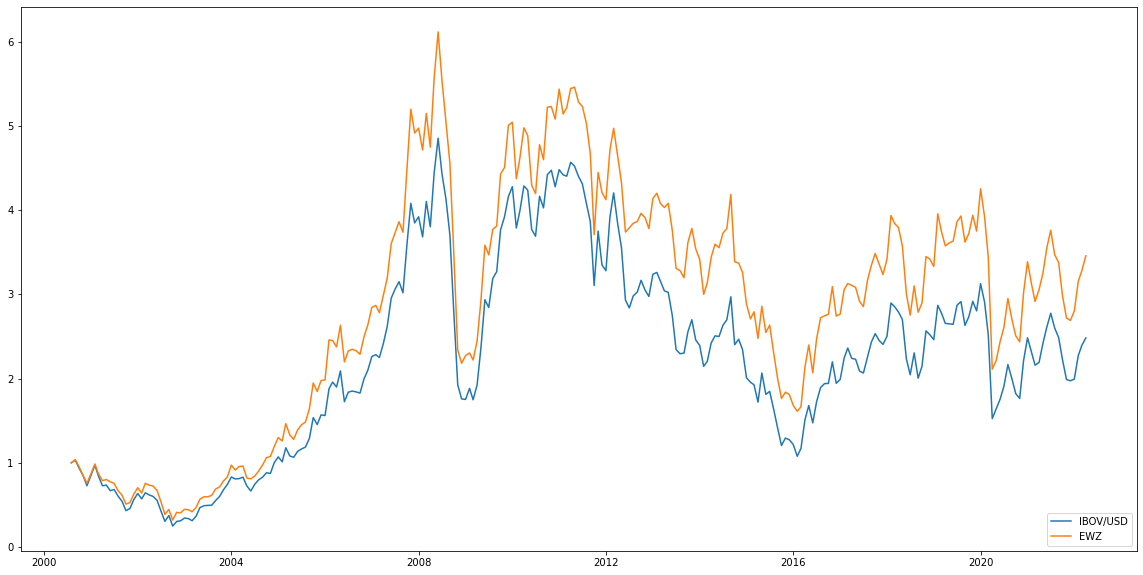

In [60]:
plt.plot(ibov_1963_df.index, ibov_1963_df['Close'], label='IBOV/USD')
plt.plot(ewz_df.index, ewz_df['Close'], label='EWZ')
plt.legend(loc='lower right')

In [61]:
ewz_df['Close'].iloc[0], ewz_df['Close'].iloc[-1]

(1.0, 3.45808119359573)

In [62]:
ibov_1963_df['Close'].iloc[0], ibov_1963_df['Close'].iloc[-1]

(1.0, 2.4823052987632206)